In [1]:
import torch
import torch.nn as nn
from transformers import CLIPModel
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设定你的本地模型路径
LOCAL_MODEL_PATH = "/mnt/workspace/FRD-CLIP/models/clip-vit-base-patch32"

class CLIPBaseline(nn.Module):
    def __init__(self, model_path=LOCAL_MODEL_PATH):
        super(CLIPBaseline, self).__init__()
        # 指向本地路径加载
        self.clip = CLIPModel.from_pretrained(model_path)
        
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, bert_input_ids, bert_attn_mask, clip_input_ids, image_tensor):
        outputs = self.clip(
            input_ids=clip_input_ids, 
            pixel_values=image_tensor, 
            return_dict=True
        )
        text_embeds = outputs.get("text_embeds")
        image_embeds = outputs.get("image_embeds")
        
        combined = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined)
        return logits

In [2]:
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, accuracy_score

def train_one_epoch(model, dataloader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss = 0.0

    # 使用 tqdm 显示 batch 进度
    for batch in tqdm(dataloader, desc="  Training Batch", leave=False):
        optimizer.zero_grad()

        # 这里的字段名需与你 Dataset 输出的 dict key 一致
        bert_input_ids   = batch["bert_input_ids"].to(device)
        bert_attn_mask   = batch["bert_attention_mask"].to(device)
        clip_input_ids   = batch["clip_input_ids"].to(device)
        image_tensor     = batch["image_tensor"].to(device)
        labels           = batch["label"].to(device)

        # 这里的参数顺序需与你 CLIPBaseline 的 forward 一致
        logits = model(bert_input_ids, bert_attn_mask,
                       clip_input_ids, image_tensor)
        
        loss = criterion(logits, labels)

        loss.backward()
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(dataloader, desc="  Evaluating Batch", leave=False):
        bert_input_ids = batch["bert_input_ids"].to(device)
        bert_attn_mask = batch["bert_attention_mask"].to(device)
        clip_input_ids = batch["clip_input_ids"].to(device)
        image_tensor   = batch["image_tensor"].to(device)
        labels         = batch["label"].to(device)

        logits = model(bert_input_ids, bert_attn_mask,
                       clip_input_ids, image_tensor)
        
        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(all_true, all_pred)
    return total_loss / len(dataloader), acc, all_true, all_pred

In [5]:
from transformers import CLIPProcessor

# 1. 定义本地模型路径（确保与你之前的 CLIPBaseline 一致）
LOCAL_MODEL_PATH = "/mnt/workspace/FRD-CLIP/models/clip-vit-base-patch32"

# 2. 从本地加载处理器
print("正在加载 CLIP 处理器...")
preprocess = CLIPProcessor.from_pretrained(LOCAL_MODEL_PATH)
print("处理器加载成功！")

正在加载 CLIP 处理器...


2026-01-25 14:09:56.270664: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 14:09:56.311768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-25 14:09:56.311789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-25 14:09:56.312789: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-25 14:09:56.319005: I tensorflow/core/platform/cpu_feature_guar

处理器加载成功！


In [12]:
import os
import requests
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from PIL import Image

def download_image(url, save_path):
    """
    下载单张图片并校验是否为有效图像文件
    """
    if os.path.exists(save_path):
        try:
            with Image.open(save_path) as img:
                img.verify() # 校验文件完整性
            return True
        except:
            os.remove(save_path) # 如果文件坏了，删掉重下

    try:
        # 增加 headers 模拟浏览器请求，防止被服务器拦截
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        resp = requests.get(url, headers=headers, timeout=15)
        if resp.status_code == 200:
            with open(save_path, 'wb') as f:
                f.write(resp.content)
            return True
    except:
        pass
    return False

def process_dataset(csv_path, save_dir, output_csv_path):
    """
    处理单个 CSV：下载图片并生成新 CSV
    """
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    
    print(f"\n正在处理: {os.path.basename(csv_path)}")
    tasks = []
    for idx, row in df.iterrows():
        url = row['image_url']
        # 提取文件名，如果 URL 没后缀则存为 .webp
        file_name = url.split('/')[-1] if '/' in url else f"{idx}.webp"
        if '.' not in file_name: file_name += ".webp"
        
        local_path = os.path.join(save_dir, file_name)
        tasks.append((url, local_path))

    # 使用多线程加速
    with ThreadPoolExecutor(max_workers=10) as executor:
        list(tqdm(executor.map(lambda x: download_image(*x), tasks), 
                  total=len(tasks), desc="Downloading"))

    # 更新路径列并保存
    df['img_local_path'] = [t[1] for t in tasks]
    df.to_csv(output_csv_path, index=False)
    print(f"完成！新 CSV 已保存至: {output_csv_path}")

# --- 开始执行 ---
base_path = "/mnt/workspace/FRD-CLIP/tmp"
img_base_dir = "/mnt/workspace/FRD-CLIP/images"

# 依次处理三个文件
datasets = ['train', 'val', 'test']

for ds in datasets:
    input_csv = f"{base_path}/{ds}.csv"
    output_csv = f"{base_path}/{ds}_ready.csv"
    save_dir = f"{img_base_dir}/{ds}" # 分文件夹存储，防止文件太多导致读取慢
    
    if os.path.exists(input_csv):
        process_dataset(input_csv, save_dir, output_csv)
    else:
        print(f"跳过: 未找到 {input_csv}")


正在处理: train.csv


Downloading: 100%|██████████| 5453/5453 [00:37<00:00, 145.04it/s]


完成！新 CSV 已保存至: /mnt/workspace/FRD-CLIP/tmp/train_ready.csv

正在处理: val.csv


Downloading: 100%|██████████| 1168/1168 [00:09<00:00, 118.42it/s]


完成！新 CSV 已保存至: /mnt/workspace/FRD-CLIP/tmp/val_ready.csv

正在处理: test.csv


Downloading: 100%|██████████| 1169/1169 [00:09<00:00, 117.06it/s]

完成！新 CSV 已保存至: /mnt/workspace/FRD-CLIP/tmp/test_ready.csv


In [13]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

class ReviewDataset(Dataset):
    def __init__(self, df, clip_processor, bert_tokenizer, max_len_bert=128, max_len_clip=77):
        """
        Args:
            df: 读取后的 DataFrame (包含 ready 后的本地路径)
            clip_processor: 加载好的 CLIPProcessor
            bert_tokenizer: 加载好的 BertTokenizer
            max_len_bert: BERT 的最大句子长度
            max_len_clip: CLIP 的最大分词长度 (默认 77)
        """
        self.df = df
        self.clip_processor = clip_processor
        self.bert_tokenizer = bert_tokenizer
        self.max_len_bert = max_len_bert
        self.max_len_clip = max_len_clip

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. 提取原始字段
        # 确保使用你下载脚本更新后的 'img_local_path' 列
        text = str(row["text_clean"]) if pd.notna(row["text_clean"]) else ""
        img_path = row["img_local_path"]
        label = int(row["label"])

        # 2. 处理 BERT 文本特征
        # BERT 负责提取深层语义特征
        bert_enc = self.bert_tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len_bert,
            return_tensors="pt"
        )

        # 3. 处理图片（带异常保护）
        image = None
        if isinstance(img_path, str) and os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert("RGB")
            except Exception:
                image = None
        
        # 如果图片不存在或损坏，生成一张全灰占位图，确保训练不中断
        if image is None:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))

        # 4. 处理 CLIP 特征 (文本 + 图像)
        # CLIP 会生成用于多模态对比的 text_embeds 和 image_embeds
        clip_enc = self.clip_processor(
            text=[text], 
            images=image, 
            return_tensors="pt", 
            padding='max_length', 
            truncation=True, 
            max_length=self.max_len_clip
        )

        # 5. 格式化输出
        # 使用 .squeeze(0) 去掉 Transformers 返回的 batch 维度，交给 DataLoader 去 stack
        return {
            "bert_input_ids": bert_enc["input_ids"].squeeze(0),
            "bert_attention_mask": bert_enc["attention_mask"].squeeze(0),
            "clip_input_ids": clip_enc["input_ids"].squeeze(0),
            "image_tensor": clip_enc["pixel_values"].squeeze(0), # 对应模型中的 pixel_values
            "label": torch.tensor(label, dtype=torch.long)
        }

# --- 准备工作 ---
from transformers import BertTokenizer, CLIPProcessor

# 加载你本地的处理器
LOCAL_CLIP_PATH = "/mnt/workspace/FRD-CLIP/models/clip-vit-base-patch32"
preprocess = CLIPProcessor.from_pretrained(LOCAL_CLIP_PATH)
LOCAL_BERT_PATH = "/mnt/workspace/FRD-CLIP/models/bert-base-chinese"
tokenizer_bert = BertTokenizer.from_pretrained(LOCAL_BERT_PATH, local_files_only=True)

# --- 加载数据 ---
train_df = pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/train_ready.csv')
val_df   = pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/val_ready.csv')
test_df  = pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/test_ready.csv')

# --- 实例化 ---
train_dataset = ReviewDataset(train_df, preprocess, tokenizer_bert)
val_dataset   = ReviewDataset(val_df, preprocess, tokenizer_bert)
test_dataset  = ReviewDataset(test_df, preprocess, tokenizer_bert)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders 已根据 CSV 原始字段重新构建完毕！")

# 5. 测试一个 Batch
batch = next(iter(train_loader))
print("测试成功！数据维度：", batch['image_tensor'].shape) # 应该是 [32, 3, 224, 224]

DataLoaders 已根据 CSV 原始字段重新构建完毕！
测试成功！数据维度： torch.Size([32, 3, 224, 224])


In [23]:
# 初始化模型与配置
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPBaseline().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_f1_0': [], 'val_f1_1': []
}

best_val_acc = 0.0
SAVE_PATH = "best_clip_baseline.pth"

# 训练循环
EPOCHS = 10
from tqdm.auto import tqdm # 自动选择 notebook 或 终端 格式

# 确保 tqdm 已经导入
# 1. 整体进度条 (Epochs)
pbar = tqdm(range(EPOCHS), desc="Total Progress")

for epoch in pbar:
    # 2. 训练阶段 (内部自带 tqdm)
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, DEVICE)
    
    # 3. 验证阶段 (内部自带 tqdm)
    val_loss, val_acc, val_true, val_pred = evaluate(model, val_loader, criterion, DEVICE)
    
    # 为了绘图完整，获取训练集 Acc
    _, train_acc, _, _ = evaluate(model, train_loader, criterion, DEVICE)
    
    # 计算每类 F1
    report = classification_report(val_true, val_pred, output_dict=True, zero_division=0)
    
    # 更新历史记录
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1_0'].append(report.get('0', {}).get('f1-score', 0)) # 鲁棒性处理
    history['val_f1_1'].append(report.get('1', {}).get('f1-score', 0))

    # 更新进度条右侧的状态文字
    pbar.set_postfix({
        "TrLoss": f"{train_loss:.3f}",
        "ValAcc": f"{val_acc:.3f}",
        "BestAcc": f"{max(best_val_acc, val_acc):.3f}"
    })

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        # 使用 tqdm.write 避免打断进度条渲染
        tqdm.write(f"Epoch {epoch+1}: New best accuracy {val_acc:.4f}! Model saved.")
    
    # 每个 epoch 结束打印一次详细报告
    tqdm.write(f"Epoch {epoch+1} Complete. Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Total Progress:   0%|          | 0/10 [00:00<?, ?it/s]

  Training Batch:   0%|          | 0/171 [00:00<?, ?it/s]

  Evaluating Batch:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluating Batch:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 1: New best accuracy 0.7543! Model saved.
Epoch 1 Complete. Val Loss: 0.6308, Val Acc: 0.7543


...

  Evaluating Batch:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluating Batch:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 3 Complete. Val Loss: 0.6308, Val Acc: 0.7543


  Training Batch:   0%|          | 0/171 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
def plot_training(history):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(15,4))

    # ---- loss / acc 曲线 ----
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='train loss')
    plt.plot(epochs, history['val_loss'], label='val loss')
    plt.title('Loss'); plt.legend(); plt.grid(False)

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_acc'], label='train acc')
    plt.plot(epochs, history['val_acc'], label='val acc')
    plt.title('Accuracy'); plt.legend(); plt.grid(False)

    # ---- 每类 F1 ----
    plt.subplot(1,3,3)
    plt.plot(epochs, history['val_f1_0'], label='real F1')
    plt.plot(epochs, history['val_f1_1'], label='fake F1')
    plt.title('F1 by class'); plt.legend(); plt.grid(False)

    plt.tight_layout(); plt.show()

    # ---- 混淆矩阵（最后一 epoch）----
    cm = confusion_matrix(val_true, val_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['real','fake'],
                yticklabels=['real','fake'],
                cmap='Blues')
    plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion Matrix')
    plt.show()

  Evaluating Batch:   0%|          | 0/37 [00:00<?, ?it/s]


Final Results on Test Set:
Test Loss: 0.646415 | Test Acc: 0.803251
------------------------------------------------------------
              precision    recall  f1-score   support

        real   0.757419  0.933227  0.836182       629
        fake   0.893401  0.651852  0.753747       540

    accuracy                       0.803251      1169
   macro avg   0.825410  0.792540  0.794965      1169
weighted avg   0.820234  0.803251  0.798103      1169



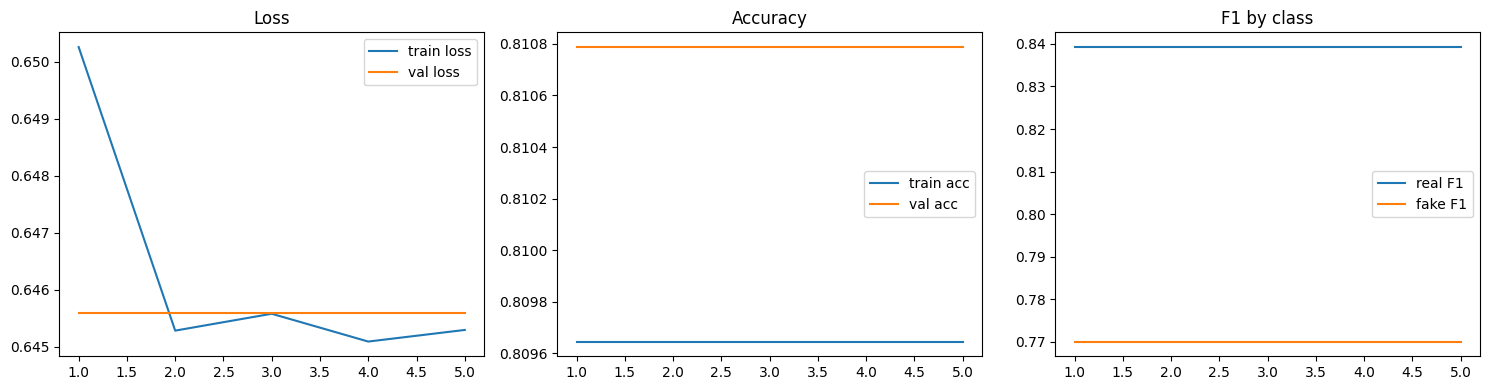

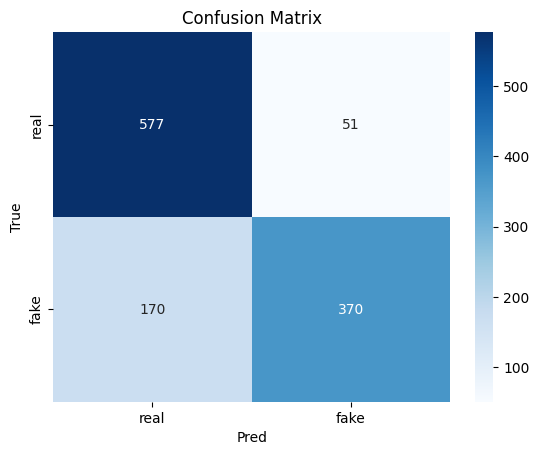

In [17]:
# 加载最佳模型进行测试
model.load_state_dict(torch.load(SAVE_PATH))
test_loss, test_acc, test_true, test_pred = evaluate(model, test_loader, criterion, DEVICE)

# 打印最终报告
print(f"\nFinal Results on Test Set:")
print(f"Test Loss: {test_loss:.6f} | Test Acc: {test_acc:.6f}")
print("-" * 60)
print(classification_report(test_true, test_pred, target_names=['real', 'fake'], digits=6))

# 调用你定义的绘图函数
plot_training(history)

In [19]:
print(model)

CLIPBaseline(
  (clip): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=True)
   